In [1]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch._utils
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# ==============================
# CONFIG: update these paths when evaluating another model run
# ==============================
DATA_DIR = "/kaggle/input/notebooks/vinphmngquc/preprocess-wlasl-datasets/dataset_landmarks"
MODEL_DIR = "/kaggle/input/notebooks/nitt25/machine-learning"
MODEL_PATH = "/kaggle/input/datasets/vitlee/wlasl-landmarks-v2/model_best.pth"
HISTORY_PATH = "/kaggle/input/datasets/vitlee/wlasl-landmarks-v2/history.npy"
OUTPUT_DIR = "/kaggle/working"
BATCH_SIZE = 32
INPUT_SIZE = 450

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 1. Định nghĩa lại Kiến trúc Model

In [2]:
class SLRNetModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
 
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),
        
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(4),
        )
        self.frame_fc = nn.Sequential(
            nn.Linear(128 * 4, 256), 
            nn.ReLU(), 
            nn.Dropout(0.3)
        )
        
        self.lstm1 = nn.LSTM(256, 128, batch_first=True)
        self.dropout1 = nn.Dropout(0.4)
 
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.dropout2 = nn.Dropout(0.4)
 
        self.fc = nn.Sequential(
            nn.Linear(64, 32), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
 
    def forward(self, x):
        B, T, F = x.shape
 
        x = x.reshape(B * T, 1, F)
        x = self.cnn(x)
        x = x.view(B*T, -1)
        x = self.frame_fc(x)
        x = x.view(B, T, -1)
 
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
 
        x = x.mean(dim=1) 
        
        return self.fc(x)

## 2. Load Dữ liệu Test và Model đã huấn luyện

In [3]:
with open(f"{DATA_DIR}/label_map.json", "r") as f:
    label_map = json.load(f)
sorted_items = sorted(label_map.items(), key=lambda item: item[1])
class_names = [name for name, idx in sorted_items]

X_test = np.load(f"{DATA_DIR}/final/X_test.npy")
y_test = np.load(f"{DATA_DIR}/final/y_test.npy")

mean = np.load("/kaggle/input/datasets/vitlee/wlasl-landmarks-v2/norm_mean.npy")
std = np.load("/kaggle/input/datasets/vitlee/wlasl-landmarks-v2/norm_std.npy")
X_test = np.clip((X_test - mean) / std, -5, 5)

if y_test.ndim > 1:
    y_test = y_test.argmax(axis=1)
y_test = y_test.astype(np.int64)

model = SLRNetModel(num_classes=len(class_names)).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False))
model.eval()
print("Model và dữ liệu thử nghiệm phiên bản mới đã sẵn sàng!")

Model và dữ liệu thử nghiệm phiên bản mới đã sẵn sàng!


## 3. Vẽ biểu đồ Learning Curve

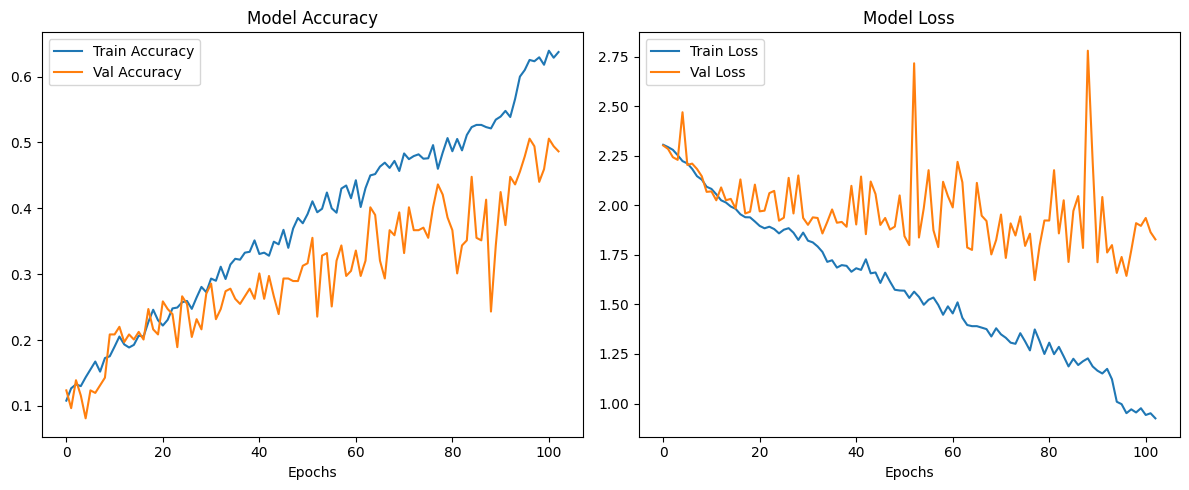

In [4]:
history = np.load(HISTORY_PATH, allow_pickle=True).item()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Đánh giá chi tiết trên tập Test

In [5]:
all_preds = []
with torch.no_grad():
    for i in range(0, len(X_test), BATCH_SIZE):
        batch = torch.tensor(X_test[i:i+BATCH_SIZE], dtype=torch.float32).to(device)
        preds = model(batch).argmax(1).cpu().numpy()
        all_preds.append(preds)
y_pred = np.concatenate(all_preds)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

print(f"Overall Accuracy : {report_dict['accuracy']:.4f}")
print(f"Macro F1         : {report_dict['macro avg']['f1-score']:.4f}")
print(f"Weighted F1      : {report_dict['weighted avg']['f1-score']:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

Overall Accuracy : 0.3900
Macro F1         : 0.3623
Weighted F1      : 0.3542

              precision    recall  f1-score   support

      FINISH       0.29      0.25      0.27        28
      FRIEND       0.55      0.63      0.59        27
        MANY       0.48      0.44      0.46        25
       NIGHT       0.00      0.00      0.00        32
        READ       0.39      0.39      0.39        28
       START       0.50      0.05      0.09        21
       WATER       0.27      0.69      0.39        26
       WHERE       0.39      0.46      0.42        26
       WRITE       0.47      0.36      0.41        25
         YOU       0.54      0.71      0.61        21

    accuracy                           0.39       259
   macro avg       0.39      0.40      0.36       259
weighted avg       0.37      0.39      0.35       259



## 5. Trực quan hóa Confusion Matrix

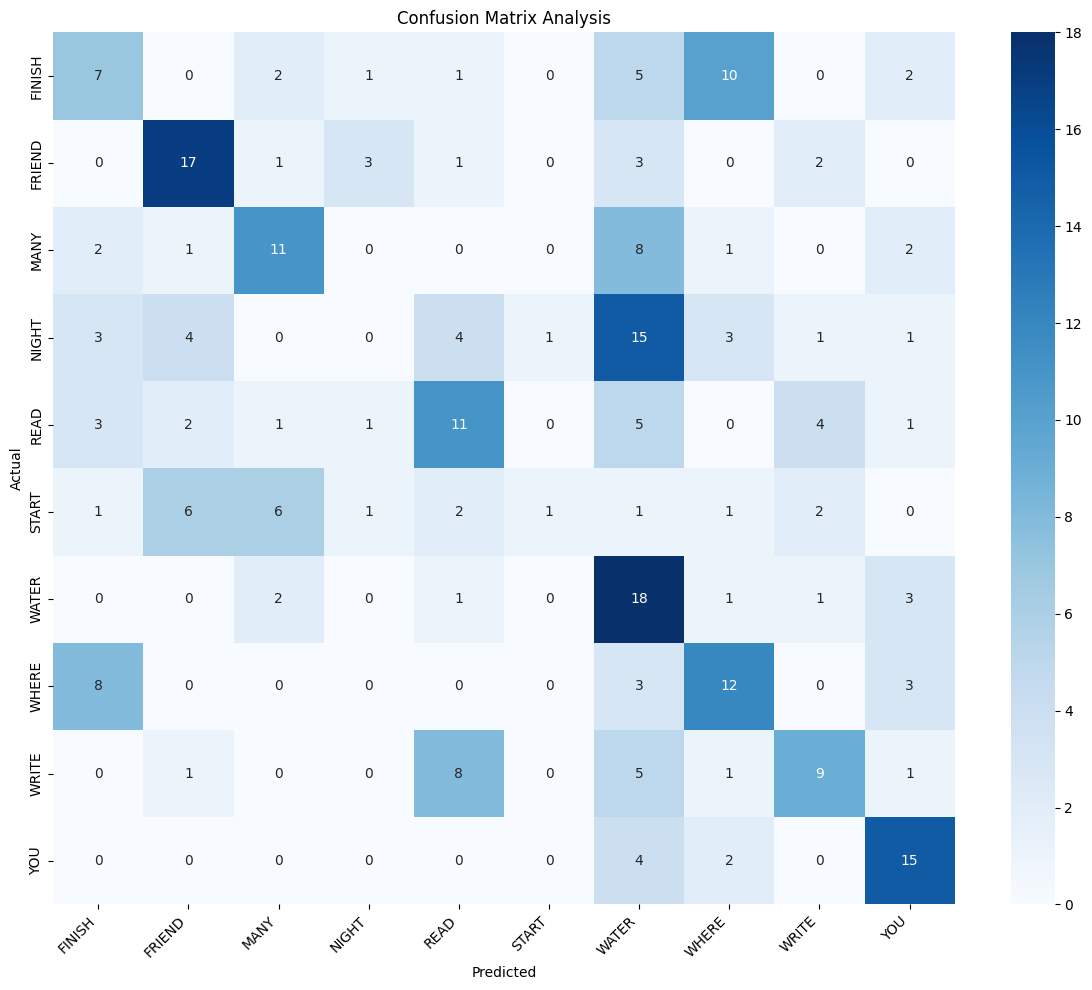

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix Analysis")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

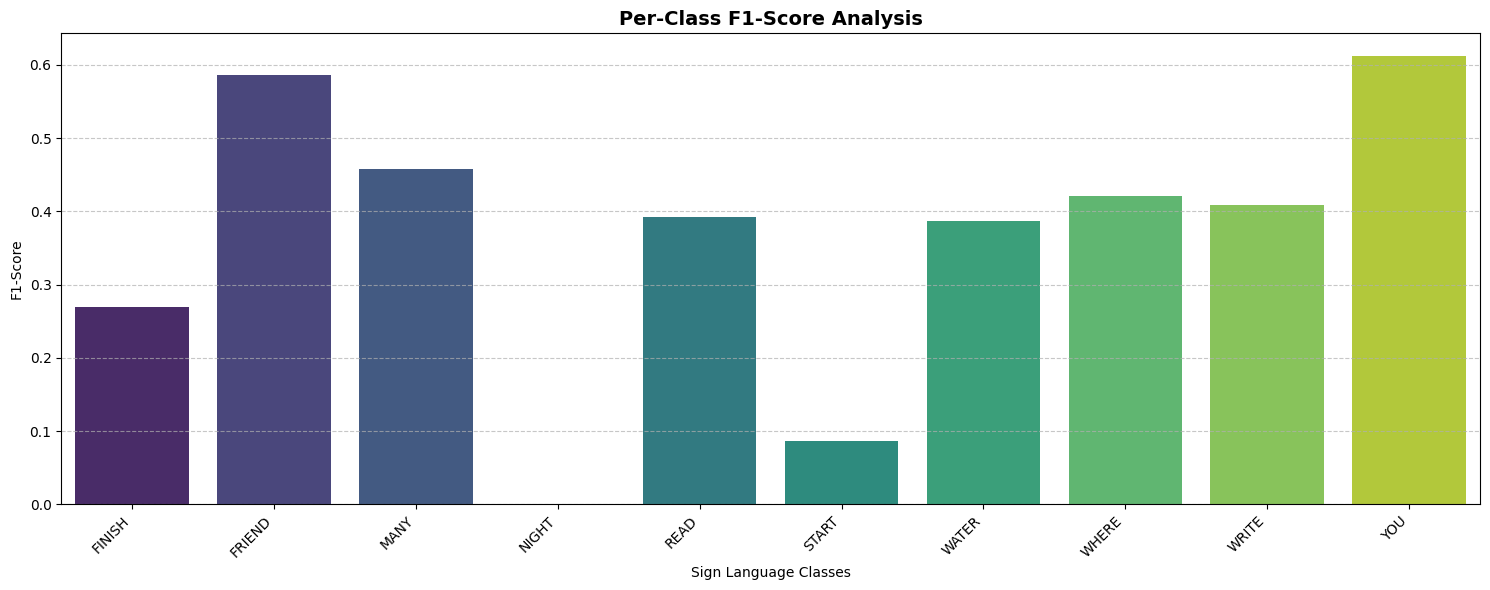

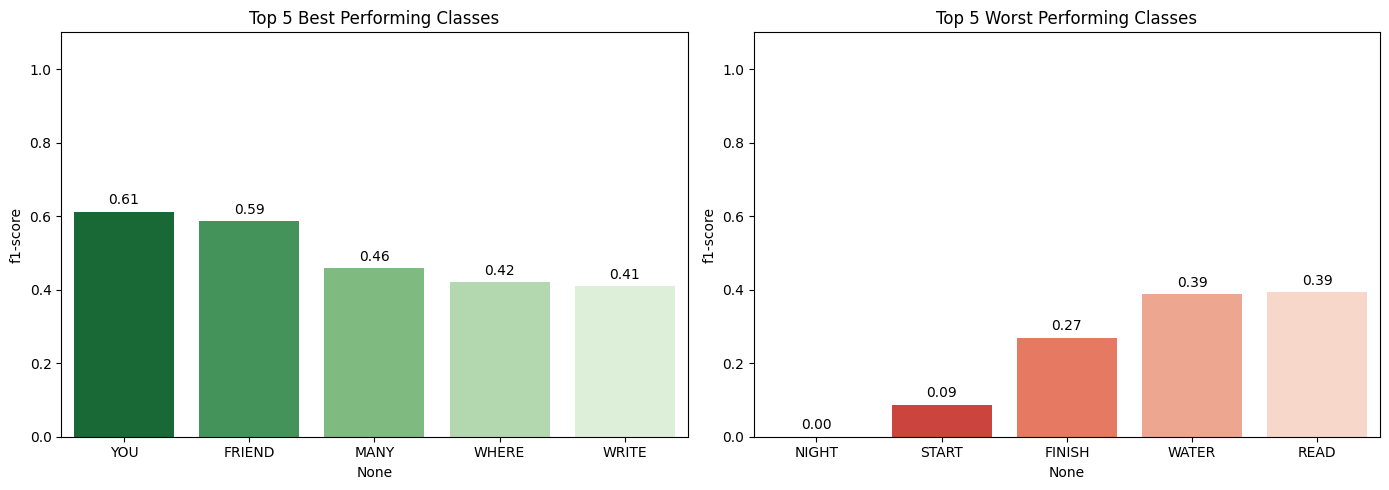


Bottom 5 Classes:
        precision    recall  f1-score
NIGHT    0.000000  0.000000  0.000000
START    0.500000  0.047619  0.086957
FINISH   0.291667  0.250000  0.269231
WATER    0.268657  0.692308  0.387097
READ     0.392857  0.392857  0.392857

Top 5 Classes:
        precision    recall  f1-score
YOU      0.535714  0.714286  0.612245
FRIEND   0.548387  0.629630  0.586207
MANY     0.478261  0.440000  0.458333
WHERE    0.387097  0.461538  0.421053
WRITE    0.473684  0.360000  0.409091


In [7]:
# ==============================
# 1. TẠO REPORT DATAFRAME
# ==============================
classes_data = {
    k: v for k, v in report_dict.items()
    if isinstance(v, dict)
}

df_report = pd.DataFrame.from_dict(classes_data, orient="index")

df_report = df_report.drop(index=[idx for idx in ["macro avg", "weighted avg"] if idx in df_report.index])

# ==============================
# 2. BIỂU ĐỒ F1-SCORE THEO CLASS
# ==============================
plt.figure(figsize=(15, 6))

sns.barplot(
    x=df_report.index,
    y=df_report['f1-score'],
    hue=df_report.index,
    palette="viridis",
    legend=False
)

plt.xticks(rotation=45, ha="right")
plt.title("Per-Class F1-Score Analysis", fontsize=14, fontweight='bold')
plt.xlabel("Sign Language Classes")
plt.ylabel("F1-Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_class_f1_score.png", dpi=150)
plt.show()

# ==============================
# 3. TOP 5 & BOTTOM 5 CLASS
# ==============================
df_sorted = df_report.sort_values(by='f1-score', ascending=False)

top_5 = df_sorted.head(5)
bottom_5 = df_sorted.tail(5).sort_values(by='f1-score', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 5
sns.barplot(
    x=top_5.index,
    y=top_5['f1-score'],
    hue=top_5.index,
    palette="Greens_r",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Top 5 Best Performing Classes")
axes[0].set_ylim(0, 1.1)

for i, v in enumerate(top_5['f1-score']):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha='center')

# Bottom 5
sns.barplot(
    x=bottom_5.index,
    y=bottom_5['f1-score'],
    hue=bottom_5.index,
    palette="Reds_r",
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Top 5 Worst Performing Classes")
axes[1].set_ylim(0, 1.1)

for i, v in enumerate(bottom_5['f1-score']):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/top_bottom_5_classes.png", dpi=150)
plt.show()

# ==============================
# 4. TÓM TẮT ĐỂ VIẾT REPORT
# ==============================
print("\nBottom 5 Classes:")
print(bottom_5[['precision', 'recall', 'f1-score']])

print("\nTop 5 Classes:")
print(top_5[['precision', 'recall', 'f1-score']])

In [8]:
# ==============================
# 5. EVALUATION SUMMARY
# ==============================
best_val_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = float(np.max(history["val_acc"]))
train_final_acc = float(history["train_acc"][-1])
val_final_acc = float(history["val_acc"][-1])
gap = train_final_acc - val_final_acc

best_class_name = top_5.index[0]
best_class_f1 = float(top_5.iloc[0]["f1-score"])
worst_class_name = bottom_5.index[0]
worst_class_f1 = float(bottom_5.iloc[0]["f1-score"])

print("\n=== Evaluation Summary ===")
print(f"Overall Accuracy   : {report_dict['accuracy']:.4f}")
print(f"Macro F1           : {report_dict['macro avg']['f1-score']:.4f}")
print(f"Weighted F1        : {report_dict['weighted avg']['f1-score']:.4f}")
print(f"Best Val Accuracy  : {best_val_acc:.4f} (epoch {best_val_epoch})")
print(f"Final Train/Val Gap : {gap:.4f}")
print(f"Best Class         : {best_class_name} ({best_class_f1:.4f})")
print(f"Worst Class        : {worst_class_name} ({worst_class_f1:.4f})")

if gap > 0.05:
    print("Note: train-val gap is noticeable, so check for mild overfitting.")
else:
    print("Note: train-val gap is small, so generalization looks stable.")



=== Evaluation Summary ===
Overall Accuracy   : 0.3900
Macro F1           : 0.3623
Weighted F1        : 0.3542
Best Val Accuracy  : 0.5058 (epoch 97)
Final Train/Val Gap : 0.1508
Best Class         : YOU (0.6122)
Worst Class        : NIGHT (0.0000)
Note: train-val gap is noticeable, so check for mild overfitting.
